# LOAD LIBRARIES

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [48]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'time_blocks_eliza'
N_FOLDS = 10
LOG_TRANSFORM = True
UNDERSAMPLE = False

# LOAD DATA

In [49]:
data_main = fluxes = load_parquet(filepath=r"111.1_GapFillingDataset.parquet", sanitize_timestamp=False)
data_main = data_main.loc[START_DATE:END_DATE].copy()

data_main

Loaded .parquet file 111.1_GapFillingDataset.parquet (0.066 seconds).


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.004965,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.003802,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.0,0.0,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.004047,0.007849,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0


# CLEAN DATA

In [50]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}\n')

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

data

The target variable is FN2O_L3.3_CUT_50_QCF0



,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.004965,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.003802,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.0,0.0,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.005286,0.010251,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0


# SELECT FEATURES

In [51]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

selected_features = [
'timesince_soil_preparation',
'wfps_0.05_gfXG_diff24h',
'wfps_0.15_gfXG_lag72h',
'ts_0.3_gfXG_lag72h',
'n_decay_timed',
'timesince_fert',
'GPP_NT_CUT_50_gfXG_QCF_lag48h'
]

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,timesince_soil_preparation,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_lag72h,ts_0.3_gfXG_lag72h,n_decay_timed,timesince_fert,GPP_NT_CUT_50_gfXG_QCF_lag48h,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,
2023-11-17,31,NaN,NaN,NaN,0.0,30,NaN,0.197910
2023-11-17,31,NaN,NaN,NaN,0.0,30,NaN,0.005580
2023-11-18,32,-3.610297,NaN,NaN,0.0,30,NaN,0.353820
2023-11-18,32,-3.610297,NaN,NaN,0.0,30,NaN,0.095548
2023-11-19,33,2.353805,NaN,NaN,0.0,30,21.721848,0.065356
...,...,...,...,...,...,...,...,...
2024-08-19,15,9.570889,36.871822,22.443279,0.0,30,26.155279,5.095387
2024-08-19,15,9.570889,36.871822,22.443279,0.0,30,26.155279,5.894838
2024-08-20,16,-2.174462,35.248474,22.228403,0.0,30,28.139108,2.381710


# IMBALANCE HANDLING

## UNDER SAMPLING

In [52]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    fraction = 0.5
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling (keeping {fraction *100} % of data) target data below: {cutoff_value}')
    data[TARGET].plot(x_compat=True, style='.', title=f'Before undersampling')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=fraction, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.', title=f'After undersampling');
else:
    print('\nThe target was not undersampled')


The target was not undersampled


## LOG TRANSFORMATION

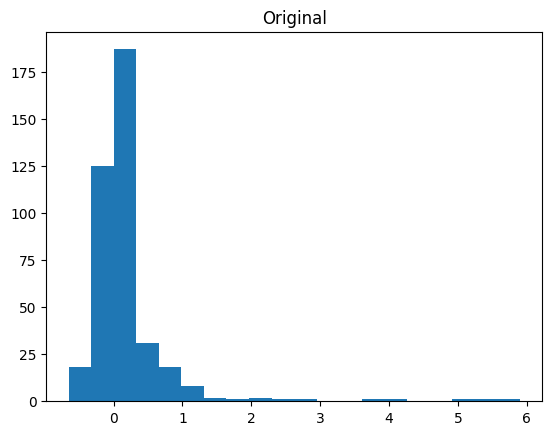

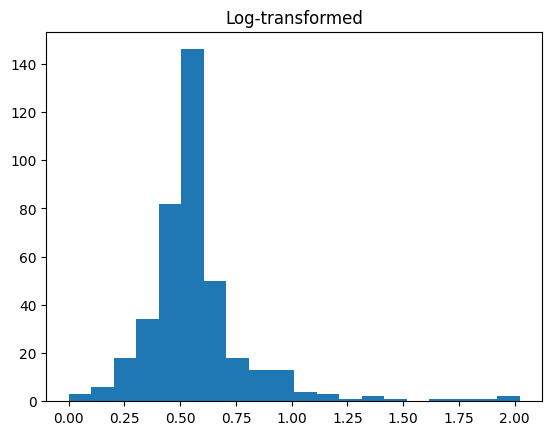

Log-tranformed
FN2O_L3.3_CUT_50_QCF0 was log-transformed


,timesince_soil_preparation,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_lag72h,ts_0.3_gfXG_lag72h,n_decay_timed,timesince_fert,GPP_NT_CUT_50_gfXG_QCF_lag48h,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,
2023-11-17,31,NaN,NaN,NaN,0.0,30,NaN,0.615918
2023-11-17,31,NaN,NaN,NaN,0.0,30,NaN,0.506230
2023-11-18,32,-3.610297,NaN,NaN,0.0,30,NaN,0.696773
2023-11-18,32,-3.610297,NaN,NaN,0.0,30,NaN,0.559040
2023-11-19,33,2.353805,NaN,NaN,0.0,30,21.721848,0.541627
...,...,...,...,...,...,...,...,...
2024-08-19,15,9.570889,36.871822,22.443279,0.0,30,26.155279,1.909369
2024-08-19,15,9.570889,36.871822,22.443279,0.0,30,26.155279,2.021320
2024-08-20,16,-2.174462,35.248474,22.228403,0.0,30,28.139108,1.395045


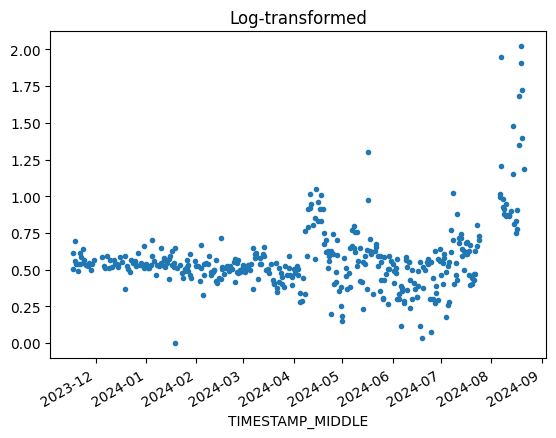

In [53]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

# Show histogram of non-tranformed and transformed TARGET
plt.hist(data[TARGET], bins=20)
plt.title('Original')
plt.show()
plt.hist(log_transform(data[TARGET]), bins=20)
plt.title('Log-transformed')
plt.show()

if LOG_TRANSFORM:
    print('Log-tranformed')
    data[TARGET] = log_transform(data[TARGET])
    print(f'{TARGET} was log-transformed')
    # Show log-transformed timeseries
    data[TARGET].plot(x_compat=True, style='.', title='Log-transformed');
else:
    print('\nLog-transformation of the target is not applied\n')

data

# CROSS-VAL SPLITS


Using time-blocks (4 records on average) splits for cross-validation



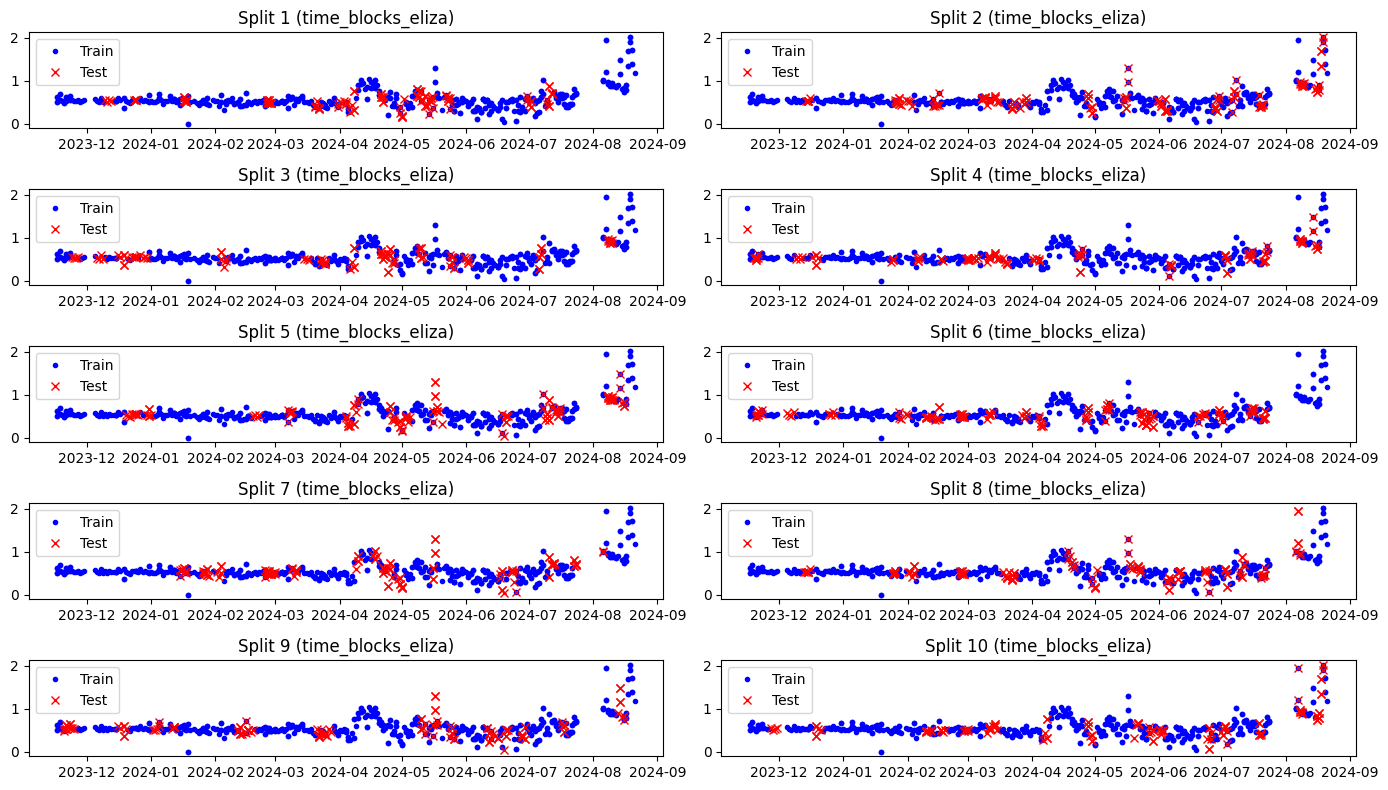

In [54]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
        print('\nUsing stratified random splits for cross-validation\n')
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)
        print('\nUsing stratified kfold splits for cross-validation\n')

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    block_size = 4 
    print(f'\nUsing time-blocks ({block_size} records on average) splits for cross-validation\n')
    def create_splits(X, y, n_folds, split=0.2, mean_block=block_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [55]:
# Convert cross-val splits into PredefinedSplit format to be able to use them in GridSearchCV
test_fold = np.full(len(data), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(cross_val_splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
predefined_cv = PredefinedSplit(test_fold)

param_grids = {
    'RandomForest': {
        'n_estimators': [50, 100, 300, 500], # Similar to XGBoost
        'max_depth': [3, 5, 10, 15], # Controls tree depth
        'min_samples_split': [2, 5, 10], # Similar to min_child_weight
        'min_samples_leaf': [1, 3, 5], # Controls leaf size
        'max_features': [0.4, 0.6, 0.8, 1.0], # Similar to colsample_bytree
    },
    'XGBoost': {
        'n_estimators': [50, 100, 300, 500],
        'gamma': [0, 0.2, 0.4],
        'max_depth': [3, 5, 10, 15],
        'learning_rate': [0.001, 0.005, 0.01, 0.05],
        'subsample': [0.65, 0.75, 1],
        'colsample_bytree': [0.4, 0.6, 0.8, 1],
        'min_child_weight': [2, 5, 10]
    }
}

model_class = RandomForestRegressor if MODEL_TYPE == 'RandomForest' else XGBRegressor
param_grid = param_grids[MODEL_TYPE]
model = model_class(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=predefined_cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(data[selected_features], data[TARGET])

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.005, 'max_depth': 10, 'min_child_weight': 2, 'n_estimators': 500, 'subsample': 0.65}


# EXPORT 

In [56]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(grid_search.best_params_, f)

# **End of notebook**

In [57]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-09 12:13:51
